In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

# Input data files are available in the read-only "../input/" directory
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
from pathlib import Path
import random

In [2]:
# Download dataset using kagglehub library
download_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')

In [3]:
# Get current directory
!pwd

/Users/aviram/mri-tumor-classification


## EDA for the dataset paths and files

In [6]:
main_path = Path(download_path)
list(main_path.iterdir())

[PosixPath('/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training'),
 PosixPath('/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Testing')]

In [7]:
training_path = main_path / 'Training'
training_subfolders = [path for path in training_path.iterdir() if path.is_dir()]
print('Training subfolders:')
print([sub_folder.name for sub_folder in training_subfolders])

testing_path = main_path / 'Testing'
testing_subfolders = [path for path in testing_path.iterdir() if path.is_dir()]
print('\nTesting subfolders:')
print([sub_folder.name for sub_folder in testing_subfolders])

Training subfolders:
['pituitary', 'notumor', 'glioma', 'meningioma']

Testing subfolders:
['pituitary', 'notumor', 'glioma', 'meningioma']


> **Conclusion: the folder names are the same.**

In [8]:
# Check the different file suffixes in the sets
training_suffixes = {file.suffix for file in training_path.rglob('*') if file.is_file()}
testing_suffixes = {file.suffix for file in testing_path.rglob('*') if file.is_file()}
print('Training file extensions:', training_suffixes)
print('Testing file extensions:', testing_suffixes)

Training file extensions: {'.jpg'}
Testing file extensions: {'.jpg'}


> **Conclusion: all the files have jpg extension.**

In [9]:
# Validate class balance in training set
count_training = {sub_train_path.name: sum(1 for _ in sub_train_path.rglob('*')) for sub_train_path in training_subfolders}
print('Count of files in the training subset:', count_training)

Count of files in the training subset: {'pituitary': 1400, 'notumor': 1400, 'glioma': 1400, 'meningioma': 1400}


In [10]:
# Validate class balance in testing set
count_testing = {sub_test_path.name: sum(1 for _ in sub_test_path.rglob('*')) for sub_test_path in testing_subfolders}
print('Count of files in the testing subset:', count_testing)

Count of files in the testing subset: {'pituitary': 400, 'notumor': 400, 'glioma': 400, 'meningioma': 400}


> **Conclusion: the classes are well-balanced and the ratio is approximately 80:20 (train/test).**

In [18]:
random.seed(42)
num_random_img = 6
train_im_paths = [file for file in training_path.rglob('*') if file.is_file()]
print(len(train_im_paths), '\n')

random_train_img = random.sample(train_im_paths, num_random_img)
for img_path in random_train_img:
    print(img_path)

5600 

/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/Tr-me_468.jpg
/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/pituitary/Tr-pi_695.jpg
/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/pituitary/Tr-pi_57.jpg
/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/notumor/Tr-no_148.jpg
/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/notumor/Tr-no_1024.jpg
/Users/aviram/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/notumor/Tr-no_779.jpg


> **Conclusion: the loading of the training image paths was successful and the path structures are visualized**

## EDA for the images

In [19]:
import cv2
import matplotlib.pyplot as plt

In [20]:
for img in random_train_img:
    img = cv2.imread(img)
    print("shape:", img.shape)
    print('dtype:', img.dtype, '\n')

shape: (225, 225, 3)
dtype: uint8 

shape: (512, 512, 3)
dtype: uint8 

shape: (512, 512, 3)
dtype: uint8 

shape: (168, 300, 3)
dtype: uint8 

shape: (442, 442, 3)
dtype: uint8 

shape: (286, 224, 3)
dtype: uint8 



> **Conclusion: the shapes are not equal, there are 3 color channels and the dtype is uint8 as expected**

## Plot random images

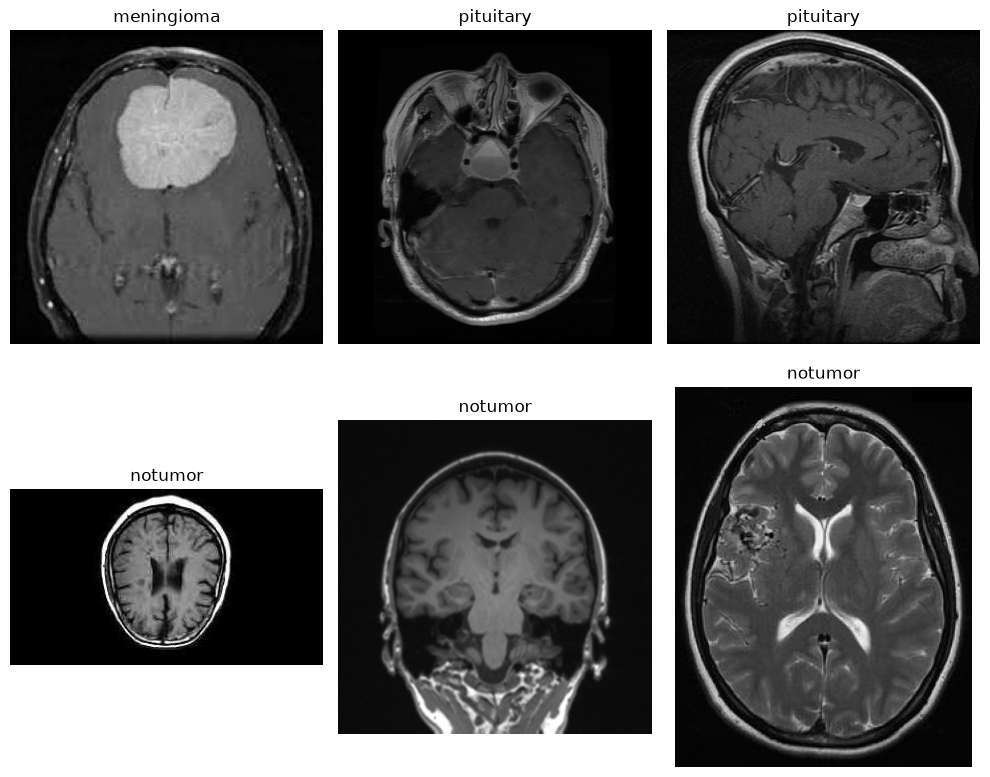

In [21]:
plt.figure(figsize=(10, 8))
for i, path in enumerate(random_train_img):
    rand_img = cv2.imread(path)
    plt.subplot(2, 3, i+1)
    plt.imshow(rand_img)
    plt.title(path.parent.name)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

## Find dimensions for resizing